In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
# Importar Dataset
df = pd.read_csv("bakery-sales.csv")

In [62]:
df.head(5)

,Unnamed: 0,date,time,ticket_number,article,Quantity,unit_price
0,0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,"0,90 €"
1,1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,"1,20 €"
2,4,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,"1,20 €"
3,5,2021-01-02,09:14,150041.0,PAIN,1.0,"1,15 €"
4,8,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,"1,20 €"


In [63]:
df.dtypes

Unnamed: 0         int64
date                 str
time                 str
ticket_number    float64
article              str
Quantity         float64
unit_price           str
dtype: object

In [64]:
df["ticket_number"] = df["ticket_number"].astype(int)
df["Quantity"] = df["Quantity"].astype(int)
df.rename(columns={"Quantity": "quantity"}, inplace=True)

In [65]:
df["unit_price"] = df["unit_price"].str.replace(" €", "").str.replace(",", ".")

In [66]:
df["date"] + " " + df["time"]

0         2021-01-02 08:38
1         2021-01-02 08:38
2         2021-01-02 09:14
3         2021-01-02 09:14
4         2021-01-02 09:25
                ...       
234000    2022-09-30 18:52
234001    2022-09-30 18:52
234002    2022-09-30 18:52
234003    2022-09-30 18:55
234004    2022-09-30 18:56
Length: 234005, dtype: str

In [67]:
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"], format="%Y-%m-%d %H:%M")

In [68]:
df.drop(columns=["Unnamed: 0", "date", "time"], inplace=True)

In [69]:
df.head()

,ticket_number,article,quantity,unit_price,datetime
0,150040,BAGUETTE,1,0.90,2021-01-02 08:38:00
1,150040,PAIN AU CHOCOLAT,3,1.20,2021-01-02 08:38:00
2,150041,PAIN AU CHOCOLAT,2,1.20,2021-01-02 09:14:00
3,150041,PAIN,1,1.15,2021-01-02 09:14:00
4,150042,TRADITIONAL BAGUETTE,5,1.20,2021-01-02 09:25:00


In [73]:
somatorio = df.groupby("article")["quantity"].sum()
valores_ordenados = somatorio.sort_values(ascending=False).head(10)
valores_ordenados

article
TRADITIONAL BAGUETTE    117463
CROISSANT                29654
PAIN AU CHOCOLAT         25236
COUPE                    23505
BANETTE                  22732
BAGUETTE                 22053
CEREAL BAGUETTE           7427
SPECIAL BREAD             5456
FORMULE SANDWICH          5181
TARTELETTE                5020
Name: quantity, dtype: int64

In [91]:
df["day_of_week"] = df["datetime"].dt.dayofweek
df["day_of_week"].unique()

array([5, 6, 0, 1, 3, 4, 2], dtype=int32)

In [95]:
day_of_week_sales = df.groupby("day_of_week")["quantity"].sum()
day_of_week_sales

day_of_week
0    47715
1    42491
2    31628
3    44924
4    48115
5    61702
6    83413
Name: quantity, dtype: int64

<BarContainer object of 7 artists>

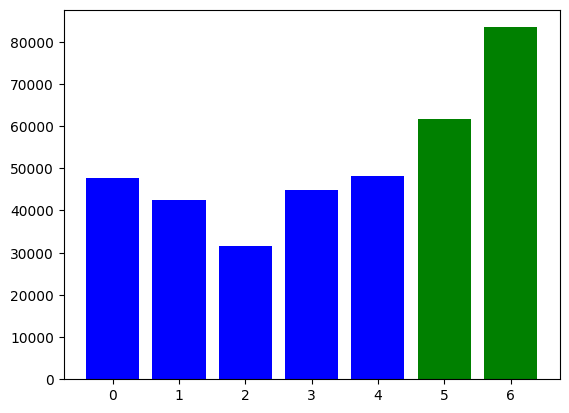

In [98]:
plt.bar(day_of_week_sales.index, day_of_week_sales.values, color=["blue", "blue", "blue", "blue", "blue", "green", "green"])